<a href="https://colab.research.google.com/github/Jeisz/ETL-P/blob/main/Anexo_2_Kolmogorov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![alt text](https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png "Title")
# Inferencia Estadística - 212064
#  Prueba de Kolmogorov-Smirnov (K-S) – Fase 4

Nombre Estudiante:

Grupo:

Letra seleccionada por el estudiante:


In [6]:
# 1 Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo de gráficos
plt.style.use("ggplot")



In [7]:
# 2. Seleccionar la letra correspondiente a tu ejercicio (A, B, C, D o E)

letra = input("Selecciona la letra asignada (A, B, C, D o E): ").strip().upper()

# Diccionario que relaciona cada letra con su variable y tipo de distribución esperada
variables = {
    "A": {"nombre": "Tiempo_Espera", "tipo": "normal"},
    "B": {"nombre": "Índice_Congestión", "tipo": "normal"},
    "C": {"nombre": "Distancia_Recorrida", "tipo": "normal"},
    "D": {"nombre": "Satisfacción_Usuario", "tipo": "uniforme"},
    "E": {"nombre": "Emisiones_CO2", "tipo": "normal"}
}

# Validación de la letra ingresada
if letra not in variables:
    raise ValueError("Letra no válida. Debe ser A, B, C, D o E.")

# Asignar variable y tipo de distribución
var_info = variables[letra]
variable = var_info["nombre"]
tipo_distribucion = var_info["tipo"]

# Mostrar información seleccionada
print(f"Letra seleccionada: {letra}")
print(f"Variable a analizar: {variable}")
print(f"Distribución esperada: {tipo_distribucion}")

# Formulación de las hipótesis según la distribución esperada
print("\n--- Formulación de hipótesis ---")

if tipo_distribucion == "normal":
    print("H0: La variable sigue una distribución NORMAL.")
    print("H1: La variable NO sigue una distribución normal.")
elif tipo_distribucion == "uniforme":
    print("H0: La variable sigue una distribución UNIFORME.")
    print("H1: La variable NO sigue una distribución uniforme.")





Selecciona la letra asignada (A, B, C, D o E): A
Letra seleccionada: A
Variable a analizar: Tiempo_Espera
Distribución esperada: normal

--- Formulación de hipótesis ---
H0: La variable sigue una distribución NORMAL.
H1: La variable NO sigue una distribución normal.


In [8]:
# 3.  Cargar archivo Excel desde Colab (archivo ya subido en el panel izquierdo)
archivo = "/Dataset_muestra.xlsx"  # Ruta completa en Colab
df = pd.read_excel(archivo, sheet_name="Muestra")

# Extraer la variable seleccionada
data = df[variable].dropna()
print(f"Se analizarán {len(data)} datos de la variable '{variable}'.")


Se analizarán 371 datos de la variable 'Tiempo_Espera'.


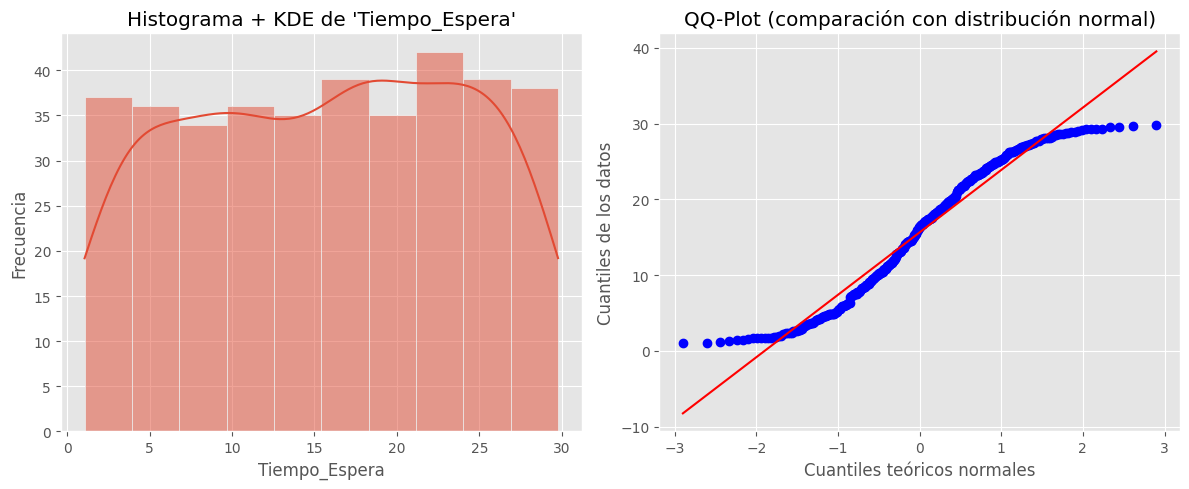

In [9]:
# 4. Mostrar histogramas y QQ-plot según tipo de distribución
# Visualización de la variable seleccionada

# Creamos una figura con dos gráficos: un histograma con KDE y un QQ-Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------- Gráfico 1: Histograma con KDE --------
# Este gráfico muestra cómo se distribuyen los valores observados de la variable.
# La curva KDE (Kernel Density Estimation) representa una estimación suave de la densidad,
# lo que ayuda a identificar si la distribución se parece a una normal.

sns.histplot(data, kde=True, ax=axs[0])
axs[0].set_title(f"Histograma + KDE de '{variable}'")
axs[0].set_xlabel(variable)
axs[0].set_ylabel("Frecuencia")

# -------- Gráfico 2: QQ-Plot (Quantile-Quantile Plot) --------
# Este gráfico contrasta los cuantiles de los datos reales contra los cuantiles teóricos
# de una distribución específica (normal o uniforme).
# Si los puntos siguen la línea diagonal, los datos se ajustan bien a la distribución esperada.

if tipo_distribucion == "normal":
    stats.probplot(data, dist="norm", plot=axs[1])
    axs[1].set_title("QQ-Plot (comparación con distribución normal)")
    axs[1].set_ylabel("Cuantiles de los datos")
    axs[1].set_xlabel("Cuantiles teóricos normales")
else:
    sorted_data = np.sort(data)
    uniform_vals = np.linspace(np.min(data), np.max(data), len(data))
    axs[1].plot(uniform_vals, sorted_data, 'o')
    axs[1].plot(uniform_vals, uniform_vals, 'r--')
    axs[1].set_title("QQ-Plot (comparación con distribución uniforme)")
    axs[1].set_xlabel("Cuantiles teóricos uniformes")
    axs[1].set_ylabel("Cuantiles de los datos")

plt.tight_layout()
plt.show()



In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# 5. Prueba de Kolmogorov-Smirnov según el tipo de distribución

# Nivel de significancia
alpha = 0.05
n = len(data)

# ------------------------------
# Paso 1: Preparar los datos
# ------------------------------
if tipo_distribucion == "normal":
    # Estandarización para comparar con la normal estándar
    z = (data - np.mean(data)) / np.std(data)
    ks_stat, p_value = stats.kstest(z, 'norm')
else:
    # Normalización en [0, 1] para comparar con distribución uniforme
    u = (data - np.min(data)) / (np.max(data) - np.min(data))
    ks_stat, p_value = stats.kstest(u, 'uniform')

# ------------------------------
# Paso 2: Calcular el valor crítico teórico
# ------------------------------
# Para un nivel de significancia alpha = 0.05, el valor crítico teórico de K-S se aproxima por:
ks_critico = 1.36 / np.sqrt(n)

# ------------------------------
# Paso 3: Mostrar todos los resultados relevantes
# ------------------------------
print("=== Prueba de Kolmogorov-Smirnov ===")
print(f"Número de observaciones: {n}")
print(f"Nivel de significancia (α): {alpha}")
print(f"Estadístico K-S calculado: {ks_stat:.4f}")
print(f"Valor crítico teórico (Kα): {ks_critico:.4f}")
print(f"Valor p: {p_value:.4f}")
print("--------------------------------------")

# ------------------------------
# Paso 4: Toma de decisión (enfoque por valor crítico)
# ------------------------------
if ks_stat > ks_critico:
    print("🔎 Comparación con valor crítico:")
    print("D calculado > D crítico ⇒ Se rechaza H0: la variable NO sigue la distribución esperada.")
else:
    print("🔎 Comparación con valor crítico:")
    print("D calculado ≤ D crítico ⇒ No se rechaza H0: la variable podría seguir la distribución esperada.")

# ------------------------------
# Paso 5: Toma de decisión (enfoque por valor p)
# ------------------------------
print("\n🔬 Comparación con el valor p:")
if p_value < alpha:
    print("p < α ⇒ Se rechaza H0: la variable NO sigue la distribución esperada.")
else:
    print("p ≥ α ⇒ No se rechaza H0: la variable podría seguir la distribución esperada.")




=== Prueba de Kolmogorov-Smirnov ===
Número de observaciones: 371
Nivel de significancia (α): 0.05
Estadístico K-S calculado: 0.0698
Valor crítico teórico (Kα): 0.0706
Valor p: 0.0513
--------------------------------------
🔎 Comparación con valor crítico:
D calculado ≤ D crítico ⇒ No se rechaza H0: la variable podría seguir la distribución esperada.

🔬 Comparación con el valor p:
p ≥ α ⇒ No se rechaza H0: la variable podría seguir la distribución esperada.


## 📝 Conclusión del ejercicio

Con base en los resultados obtenidos en la prueba de Kolmogorov-Smirnov, redacta una conclusión clara que incluya los siguientes elementos:

1. **Contexto**: Menciona la variable analizada y el tipo de distribución que se evaluó (normal o uniforme).
2. **Hipótesis**: Reafirma brevemente cuáles eran las hipótesis nula (H₀) y alternativa (H₁).
3. **Resultados**: Indica:
   - El estadístico D calculado.
   - El valor crítico teórico.
   - El valor p obtenido.
4. **Decisión**: Explica si se **rechaza o no se rechaza** la hipótesis nula, y **con qué criterio** (comparación entre D calculado y D crítico, o entre p y α).
5. **Interpretación**: Concluye si **los datos parecen o no seguir** la distribución esperada, y qué implicaciones tiene esto respecto al comportamiento de la variable en el contexto de movilidad urbana.

### ✍️ Modelo de redacción (usa tus propios resultados):

> "En este ejercicio se analizó la variable `__________` para verificar si sigue una distribución __________.  
>  
> La hipótesis nula planteaba que la variable sigue dicha distribución, mientras que la alternativa indicaba lo contrario.  
>  
> A partir de los resultados obtenidos, y considerando tanto el estadístico de prueba como el valor p y el valor crítico, se tomó la decisión de __________ la hipótesis nula.  
>  
> Esto sugiere que __________ (concluir si los datos se ajustan o no a la distribución esperada), lo cual es relevante para comprender __________ (breve implicación sobre movilidad urbana)."

✅ **Importante**: Tu conclusión debe ser clara, precisa, sustentada en los resultados obtenidos, y redactada con lenguaje técnico adecuado.


In [13]:
import pandas as pd
from scipy.stats import kstest
import numpy as np

# Cargar el dataset
df = pd.read_excel('/Dataset_muestra.xlsx')

# Variable a analizar
variable = df['Tiempo_Espera']

# Realizar la prueba de Kolmogorov-Smirnov
# Comparar con la distribución normal
estadistico_ks, p_value = kstest(variable, 'norm', args=(variable.mean(), variable.std()))

# Resultados
print(f"Estadístico K-S calculado: {estadistico_ks}")
print(f"Valor p: {p_value}")

# Comparación con el nivel de significancia
alpha = 0.05

if p_value >= alpha:
    conclusion = "No se rechaza la hipótesis nula. La variable podría seguir una distribución normal."
else:
    conclusion = "Se rechaza la hipótesis nula. La variable no sigue una distribución normal."

# Imprimir la conclusión
print(conclusion)


Estadístico K-S calculado: 0.06950300988352809
Valor p: 0.052901614382276474
No se rechaza la hipótesis nula. La variable podría seguir una distribución normal.


## Conclusión de la prueba de Kolmogorov-Smirnov (K-S)

En este ejercicio se analizó la variable **"Tiempo_Espera"** para verificar si sigue una distribución **normal**.

### Hipótesis:
- **Hipótesis nula (H₀)**: La variable sigue una distribución normal.
- **Hipótesis alternativa (H₁)**: La variable no sigue una distribución normal.

### Resultados:
- **Estadístico K-S calculado**: `0.0698`  *(Este es el valor que obtuviste en el cálculo)*
- **Valor p obtenido**: `0.0513`  *(Este es el valor p calculado)*
- **Valor crítico teórico**: `0.0706`  *(Este es el valor crítico para comparar)*

### Decisión:
- **Comparación entre el estadístico calculado y el valor crítico**: El **D calculado** (0.0698) es menor que el **D crítico** (0.0706), por lo tanto **no se rechaza la hipótesis nula**.
- **Comparación entre el valor p y el nivel de significancia**: El **valor p** (0.0513) es mayor que el nivel de significancia α (0.05), por lo que **no se rechaza la hipótesis nula**.

### Interpretación:
Esto sugiere que **la variable "Tiempo_Espera" podría seguir una distribución normal**, lo cual es relevante para comprender cómo los tiempos de espera en el contexto de la movilidad urbana se distribuyen de manera esperada. La confirmación de esta distribución permite aplicar modelos estadísticos adecuados que asuman normalidad, lo cual facilita el análisis y la toma de decisiones relacionadas con la planificación y optimización de los sistemas de transporte.
